#ROC  and KFold

## Attribution
Please supply all citations that you used to complete this assignment. They should be in APA format.


1.   Citation here.
2.   and here.
3.   and here....

## Acknowledgement

 <cite>
Taiwanese Bankruptcy Prediction [Dataset]. (2020). UCI Machine Learning Repository. https://doi.org/10.24432/C5004D.

https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc_crossval.html#sphx-glr-auto-examples-model-selection-plot-roc-crossval-py

 <cite>


In [3]:
%%capture
!pip install ucimlrepo

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn import svm, datasets
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from ucimlrepo import fetch_ucirepo
import matplotlib.pyplot as plt

from sklearn import svm
from sklearn.metrics import RocCurveDisplay, auc
from sklearn.model_selection import StratifiedKFold

In [5]:
#@title Data for Lab
def getData(n):
  # fetch dataset
  taiwanese_bankruptcy_prediction = fetch_ucirepo(id=572)

  # data (as pandas dataframes)


  X = np.array(taiwanese_bankruptcy_prediction.data.features.iloc[:, 0:n].values.tolist())
  y = np.array(taiwanese_bankruptcy_prediction.data.targets.values.tolist()).ravel()
  print(X[0:5])
  return X,y


In [6]:
import warnings
warnings.filterwarnings('ignore')
#@title Plot for Lab
def plot(n,X,y):
  cv = StratifiedKFold(n_splits=n)
  classifier = svm.SVC(kernel="linear", probability=True, random_state=10,max_iter=500)
  tprs = []
  aucs = []
  mean_fpr = np.linspace(0, 1, 100)

  fig, ax = plt.subplots(figsize=(6, 6))
  for fold, (train, test) in enumerate(cv.split(X, y)):
      ### Add normalize and StandardScaler here
      ### Make sure you do training and testing separately.
      classifier.fit(X[train], y[train])
      viz = RocCurveDisplay.from_estimator(
          classifier,
          X[test],
          y[test],
          name=f"ROC fold {fold}",
          alpha=0.3,
          lw=1,
          ax=ax,
          plot_chance_level=(fold == n_splits - 1),
      )
      interp_tpr = np.interp(mean_fpr, viz.fpr, viz.tpr)
      interp_tpr[0] = 0.0
      tprs.append(interp_tpr)
      aucs.append(viz.roc_auc)

  mean_tpr = np.mean(tprs, axis=0)
  mean_tpr[-1] = 1.0
  mean_auc = auc(mean_fpr, mean_tpr)
  std_auc = np.std(aucs)


  std_tpr = np.std(tprs, axis=0)
  tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
  tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
  ax.fill_between(
      mean_fpr,
      tprs_lower,
      tprs_upper,
      color="grey",
      alpha=0.2,
      label=r"$\pm$ 1 std. dev.",
  )

  ax.set(
      xlabel="False Positive Rate",
      ylabel="True Positive Rate",
      title=f"Mean ROC curve with variability\n(Positive label)",
  )
  ax.legend(loc="lower right")
  plt.show()


## Example Output

For this lab you only need to change number_of_columns and n_splits.

[[0.37059426]
 [0.46429094]
 [0.42607127]
 [0.399844  ]
 [0.46502218]]


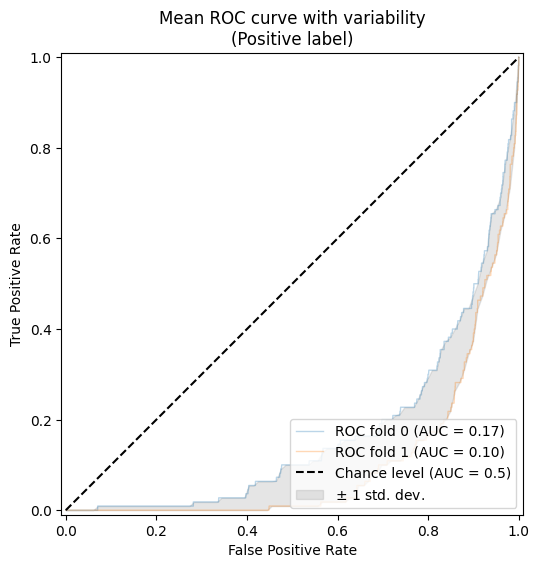

In [7]:
number_of_columns = 1
n_splits = 2
X,y = getData(number_of_columns)
plot(n_splits,X,y)

## TO-DO

run this for:

number_of_columns = 1

n_splits = 10

Answer: Why are these folds not all the same?
It is using a different subset of data for training and testing for every fold and there's only 1 feature.

[[0.37059426]
 [0.46429094]
 [0.42607127]
 [0.399844  ]
 [0.46502218]]


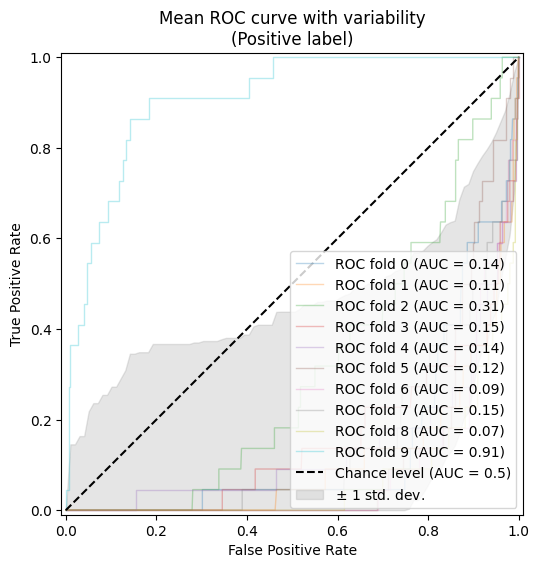

In [55]:
number_of_columns = 1
n_splits = 10
X,y = getData(number_of_columns)
plot(n_splits,X,y)

## TO-DO

Run this for:

number_of_columns = 5 and 10

n_splits = 10

Answer: Are there significant difference between the folds? Yes/No and why?
No, there is not that much of a significant difference. This is because more features means less sensitivity to the samples in the fold.

[[0.37059426 0.42438945 0.40574977 0.60145721 0.60145721]
 [0.46429094 0.53821413 0.51673002 0.61023509 0.61023509]
 [0.42607127 0.49901875 0.47229509 0.60145001 0.60136352]
 [0.399844   0.45126472 0.45773328 0.58354113 0.58354113]
 [0.46502218 0.53843218 0.52229777 0.59878349 0.59878349]]


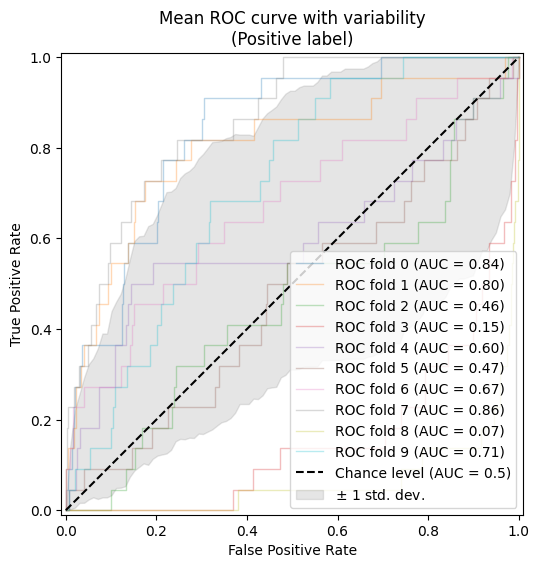

In [9]:
number_of_columns = 5
n_splits = 10
X,y = getData(number_of_columns)
plot(n_splits,X,y)

[[0.37059426 0.42438945 0.40574977 0.60145721 0.60145721 0.9989692
  0.79688715 0.80880936 0.30264643 0.78098485]
 [0.46429094 0.53821413 0.51673002 0.61023509 0.61023509 0.99894598
  0.79738019 0.80930073 0.30355643 0.78150597]
 [0.42607127 0.49901875 0.47229509 0.60145001 0.60136352 0.99885735
  0.79640337 0.80838752 0.30203518 0.78028394]
 [0.399844   0.45126472 0.45773328 0.58354113 0.58354113 0.99869975
  0.79696697 0.8089656  0.30334954 0.78124099]
 [0.46502218 0.53843218 0.52229777 0.59878349 0.59878349 0.99897313
  0.79736608 0.80930372 0.30347498 0.78155004]]


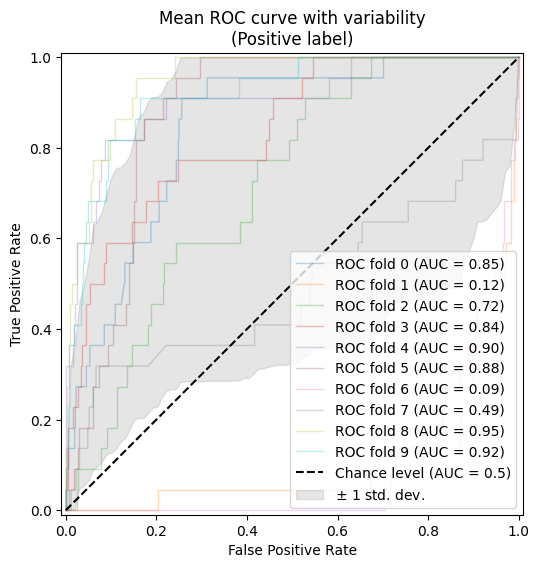

In [10]:
number_of_columns = 10
n_splits = 10
X,y = getData(number_of_columns)
plot(n_splits,X,y)

## TO-DO

run this for:

number_of_columns = 11

n_splits = 10

Answer: What happened here? Feature 11 messed up the model, it could be random noise or contradictory from the other features.

The Column is called: Operating Expense Rate

[[3.70594257e-01 4.24389446e-01 4.05749772e-01 6.01457213e-01
  6.01457213e-01 9.98969203e-01 7.96887146e-01 8.08809361e-01
  3.02646434e-01 7.80984850e-01 1.25696869e-04]
 [4.64290937e-01 5.38214130e-01 5.16730018e-01 6.10235086e-01
  6.10235086e-01 9.98945978e-01 7.97380191e-01 8.09300726e-01
  3.03556430e-01 7.81505974e-01 2.89785054e-04]
 [4.26071272e-01 4.99018753e-01 4.72295091e-01 6.01450006e-01
  6.01363525e-01 9.98857353e-01 7.96403369e-01 8.08387521e-01
  3.02035177e-01 7.80283936e-01 2.36129721e-04]
 [3.99844001e-01 4.51264719e-01 4.57733283e-01 5.83541129e-01
  5.83541129e-01 9.98699747e-01 7.96966968e-01 8.08965598e-01
  3.03349536e-01 7.81240991e-01 1.07888849e-04]
 [4.65022181e-01 5.38432185e-01 5.22297768e-01 5.98783494e-01
  5.98783494e-01 9.98973132e-01 7.97366081e-01 8.09303720e-01
  3.03474978e-01 7.81550045e-01 7.89000000e+09]]


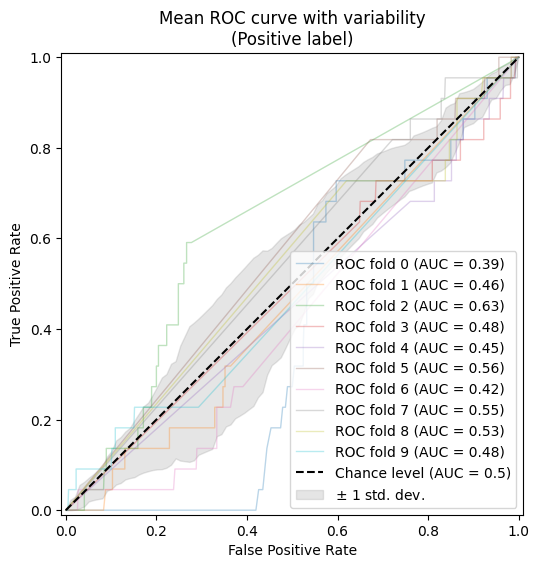

In [11]:
number_of_columns = 11
n_splits = 10
X,y = getData(number_of_columns)
plot(n_splits,X,y)

## TO-DO

Run this for number_of_columns > 11 (up to 13 columns)

Does adding more columns help?
13 and above make it better.

[[3.70594257e-01 4.24389446e-01 4.05749772e-01 6.01457213e-01
  6.01457213e-01 9.98969203e-01 7.96887146e-01 8.08809361e-01
  3.02646434e-01 7.80984850e-01 1.25696869e-04 0.00000000e+00
  4.58143144e-01]
 [4.64290937e-01 5.38214130e-01 5.16730018e-01 6.10235086e-01
  6.10235086e-01 9.98945978e-01 7.97380191e-01 8.09300726e-01
  3.03556430e-01 7.81505974e-01 2.89785054e-04 0.00000000e+00
  4.61867257e-01]
 [4.26071272e-01 4.99018753e-01 4.72295091e-01 6.01450006e-01
  6.01363525e-01 9.98857353e-01 7.96403369e-01 8.08387521e-01
  3.02035177e-01 7.80283936e-01 2.36129721e-04 2.55000000e+07
  4.58520587e-01]
 [3.99844001e-01 4.51264719e-01 4.57733283e-01 5.83541129e-01
  5.83541129e-01 9.98699747e-01 7.96966968e-01 8.08965598e-01
  3.03349536e-01 7.81240991e-01 1.07888849e-04 0.00000000e+00
  4.65705443e-01]
 [4.65022181e-01 5.38432185e-01 5.22297768e-01 5.98783494e-01
  5.98783494e-01 9.98973132e-01 7.97366081e-01 8.09303720e-01
  3.03474978e-01 7.81550045e-01 7.89000000e+09 0.00000000e+0

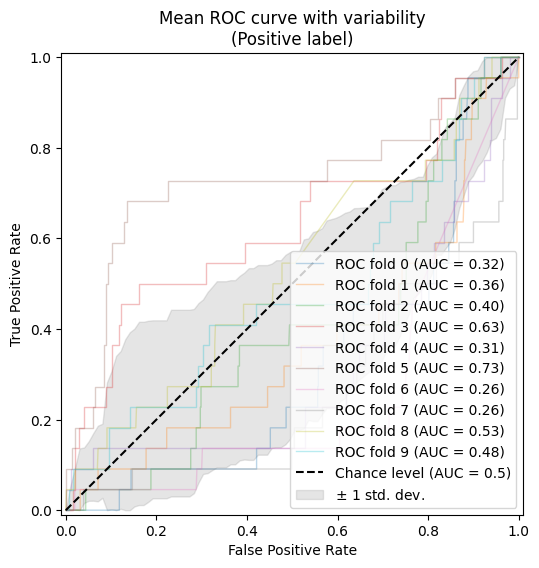

In [12]:
number_of_columns = 13
n_splits = 10
X,y = getData(number_of_columns)
plot(n_splits,X,y)

## Normalization and Standardization

We are going to see if normalization can help with this issue.

Here is a simple example of options for normalization.

In [13]:
from sklearn import preprocessing
X = [[ 1., -1.,  2.],
     [ 2.,  0.,  0.],
     [ 0.,  1., -1.]]
X_normalized = preprocessing.normalize(X, norm='l1')

X_normalized

array([[ 0.25, -0.25,  0.5 ],
       [ 1.  ,  0.  ,  0.  ],
       [ 0.  ,  0.5 , -0.5 ]])

In [14]:
from sklearn import preprocessing
X = [[ 1., -1.,  2.],
     [ 2.,  0.,  0.],
     [ 0.,  1., -1.]]
X_normalized = preprocessing.normalize(X, norm='l1', axis=0)

X_normalized

array([[ 0.33333333, -0.5       ,  0.66666667],
       [ 0.66666667,  0.        ,  0.        ],
       [ 0.        ,  0.5       , -0.33333333]])

In [15]:
from sklearn import preprocessing
X = [[ 1., -1.,  2.],
     [ 2.,  0.,  0.],
     [ 0.,  1., -1.]]
X_normalized = preprocessing.normalize(X, norm='l2')

X_normalized

array([[ 0.40824829, -0.40824829,  0.81649658],
       [ 1.        ,  0.        ,  0.        ],
       [ 0.        ,  0.70710678, -0.70710678]])

In [16]:
from sklearn import preprocessing
X = [[ 1., -1.,  2.],
     [ 2.,  0.,  0.],
     [ 0.,  1., -1.]]
X_normalized = preprocessing.normalize(X, norm='l2', axis=0)

X_normalized

array([[ 0.4472136 , -0.70710678,  0.89442719],
       [ 0.89442719,  0.        ,  0.        ],
       [ 0.        ,  0.70710678, -0.4472136 ]])

In [17]:
from sklearn import preprocessing
X = [[ 1., -1.,  2.],
     [ 2.,  0.,  0.],
     [ 0.,  1., -1.]]

scaler = preprocessing.StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 0.        , -1.22474487,  1.33630621],
       [ 1.22474487,  0.        , -0.26726124],
       [-1.22474487,  1.22474487, -1.06904497]])

###

In [18]:
from sklearn import preprocessing
X = [[ 1., -1.,  2.],
     [ 2.,  0.,  0.],
     [ 0.,  1., -1.]]
X_normalized = preprocessing.normalize(X, norm='l1')
scaler = preprocessing.StandardScaler()
X_scaled = scaler.fit_transform(X_normalized)
X_scaled

array([[-0.39223227, -1.06904497,  1.22474487],
       [ 1.37281295, -0.26726124,  0.        ],
       [-0.98058068,  1.33630621, -1.22474487]])

# TO-DO

Copy and Paste the "Plot for Lab"

Change the function name (below is an example, where I change it to plot2)

ReRun this for:

number_of_columns = 11

n_splits = 10

normalize(X, norm='l1')

and

Repeat for:

normalize(X, norm='l1', axis=0)

normalize(X, norm='l2')

normalize(X, norm='l2', axis=0)

In [19]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import normalize, StandardScaler

def plot2(n, X, y):

  cv = StratifiedKFold(n_splits=n)
  classifier = svm.SVC(kernel="linear", probability=True, random_state=10, max_iter=500)

  tprs = []
  aucs = []
  mean_fpr = np.linspace(0, 1, 100)

  fig, ax = plt.subplots(figsize=(6, 6))

  for fold, (train, test) in enumerate(cv.split(X, y)):

      X_train = X[train]
      X_test  = X[test]

      X_train = normalize(X_train, norm='l1')
      X_test  = normalize(X_test,  norm='l1')

      # standardize
      scaler = StandardScaler()
      X_train = scaler.fit_transform(X_train)
      X_test  = scaler.transform(X_test)

      classifier.fit(X_train, y[train])

      viz = RocCurveDisplay.from_estimator(
          classifier,
          X_test,
          y[test],
          name=f"ROC fold {fold}",
          alpha=0.3,
          lw=1,
          ax=ax,
          plot_chance_level=(fold == n - 1),
      )

      interp_tpr = np.interp(mean_fpr, viz.fpr, viz.tpr)
      interp_tpr[0] = 0.0
      tprs.append(interp_tpr)
      aucs.append(viz.roc_auc)

  mean_tpr = np.mean(tprs, axis=0)
  mean_tpr[-1] = 1.0
  mean_auc = auc(mean_fpr, mean_tpr)

  std_tpr = np.std(tprs, axis=0)
  tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
  tprs_lower = np.maximum(mean_tpr - std_tpr, 0)

  ax.fill_between(mean_fpr, tprs_lower, tprs_upper,
                  color="grey", alpha=0.2,
                  label=r"$\pm$ 1 std. dev.")

  ax.set(
      xlabel="False Positive Rate",
      ylabel="True Positive Rate",
      title="ROC with L1 normalization"
  )

  ax.legend(loc="lower right")
  plt.show()


[[3.70594257e-01 4.24389446e-01 4.05749772e-01 6.01457213e-01
  6.01457213e-01 9.98969203e-01 7.96887146e-01 8.08809361e-01
  3.02646434e-01 7.80984850e-01 1.25696869e-04]
 [4.64290937e-01 5.38214130e-01 5.16730018e-01 6.10235086e-01
  6.10235086e-01 9.98945978e-01 7.97380191e-01 8.09300726e-01
  3.03556430e-01 7.81505974e-01 2.89785054e-04]
 [4.26071272e-01 4.99018753e-01 4.72295091e-01 6.01450006e-01
  6.01363525e-01 9.98857353e-01 7.96403369e-01 8.08387521e-01
  3.02035177e-01 7.80283936e-01 2.36129721e-04]
 [3.99844001e-01 4.51264719e-01 4.57733283e-01 5.83541129e-01
  5.83541129e-01 9.98699747e-01 7.96966968e-01 8.08965598e-01
  3.03349536e-01 7.81240991e-01 1.07888849e-04]
 [4.65022181e-01 5.38432185e-01 5.22297768e-01 5.98783494e-01
  5.98783494e-01 9.98973132e-01 7.97366081e-01 8.09303720e-01
  3.03474978e-01 7.81550045e-01 7.89000000e+09]]


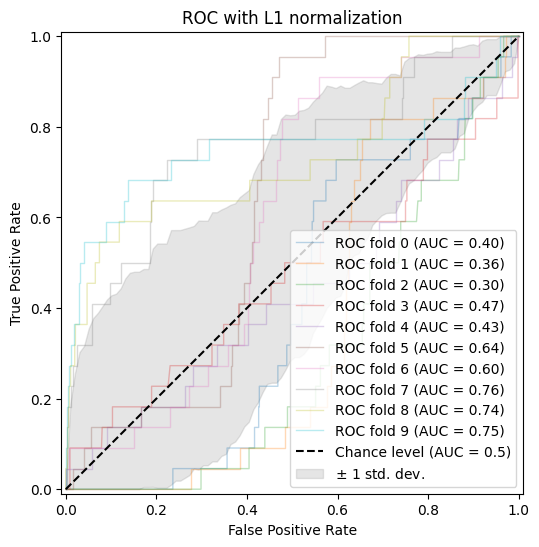

In [20]:
number_of_columns = 11
n_splits = 10

X, y = getData(number_of_columns)
plot2(n_splits, X, y)




In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import auc


[[3.70594257e-01 4.24389446e-01 4.05749772e-01 6.01457213e-01
  6.01457213e-01 9.98969203e-01 7.96887146e-01 8.08809361e-01
  3.02646434e-01 7.80984850e-01 1.25696869e-04]
 [4.64290937e-01 5.38214130e-01 5.16730018e-01 6.10235086e-01
  6.10235086e-01 9.98945978e-01 7.97380191e-01 8.09300726e-01
  3.03556430e-01 7.81505974e-01 2.89785054e-04]
 [4.26071272e-01 4.99018753e-01 4.72295091e-01 6.01450006e-01
  6.01363525e-01 9.98857353e-01 7.96403369e-01 8.08387521e-01
  3.02035177e-01 7.80283936e-01 2.36129721e-04]
 [3.99844001e-01 4.51264719e-01 4.57733283e-01 5.83541129e-01
  5.83541129e-01 9.98699747e-01 7.96966968e-01 8.08965598e-01
  3.03349536e-01 7.81240991e-01 1.07888849e-04]
 [4.65022181e-01 5.38432185e-01 5.22297768e-01 5.98783494e-01
  5.98783494e-01 9.98973132e-01 7.97366081e-01 8.09303720e-01
  3.03474978e-01 7.81550045e-01 7.89000000e+09]]


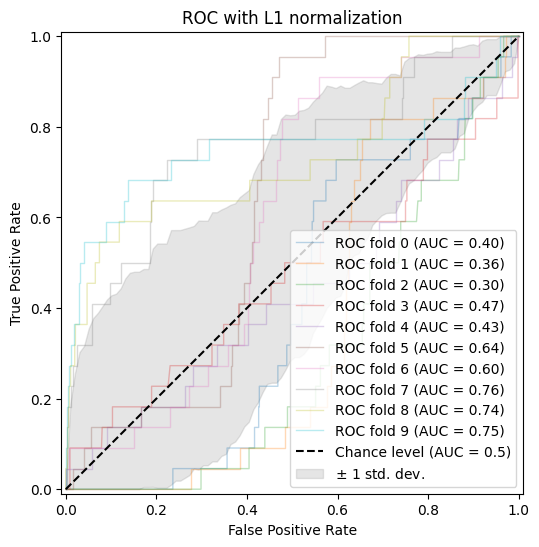

In [52]:
#normalize(X, norm='l1')
#number_of_columns = 11
#n_splits = 10
#X,y = getData(number_of_columns)
#plot2(n_splits,X,y)

In [44]:
#@title Plot3 for Lab
#def plot3(n,X,y):
#print("add code here")

In [45]:
# normalize(X, norm='l1', axis=0)
#number_of_columns = 11
#n_splits = 10
#X, y = getData(number_of_columns)
#plot3(n_splits, X, y)


In [25]:
#####################################################################################################################

In [67]:
import warnings
warnings.filterwarnings('ignore')
#@title Plot3 for Lab L1 axis = 0
def plot3(n,X,y):
  cv = StratifiedKFold(n_splits=n)
  classifier = svm.SVC(kernel="linear", probability=True, random_state=10,max_iter=500)
  tprs = []
  aucs = []
  mean_fpr = np.linspace(0, 1, 100)

  fig, ax = plt.subplots(figsize=(6, 6))
  for fold, (train, test) in enumerate(cv.split(X, y)):
      ### Add normalize and StandardScaler here
      ### Make sure you do training and testing separately.

      X_train = X[train]
      X_test  = X[test]

      X_train = normalize(X_train, norm='l1', axis=0)
      X_test  = normalize(X_test,  norm='l1', axis=0)


      # standardize
      scaler = StandardScaler()
      X_train = scaler.fit_transform(X_train)
      X_test  = scaler.transform(X_test)


      classifier.fit(X_train, y[train])
      viz = RocCurveDisplay.from_estimator(
          classifier,
          X_test,
          y[test],
          name=f"ROC fold {fold}",
          alpha=0.3,
          lw=1,
          ax=ax,
          plot_chance_level=(fold == n - 1),
      )
      interp_tpr = np.interp(mean_fpr, viz.fpr, viz.tpr)
      interp_tpr[0] = 0.0
      tprs.append(interp_tpr)
      aucs.append(viz.roc_auc)

  mean_tpr = np.mean(tprs, axis=0)
  mean_tpr[-1] = 1.0
  mean_auc = auc(mean_fpr, mean_tpr)
  std_auc = np.std(aucs)


  std_tpr = np.std(tprs, axis=0)
  tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
  tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
  ax.fill_between(
      mean_fpr,
      tprs_lower,
      tprs_upper,
      color="grey",
      alpha=0.2,
      label=r"$\pm$ 1 std. dev.",
  )

  ax.set(
      xlabel="False Positive Rate",
      ylabel="True Positive Rate",
      title=f"Mean ROC curve with variability\n(Positive label)",
  )
  ax.legend(loc="lower right")
  plt.show()

[[3.70594257e-01 4.24389446e-01 4.05749772e-01 6.01457213e-01
  6.01457213e-01 9.98969203e-01 7.96887146e-01 8.08809361e-01
  3.02646434e-01 7.80984850e-01 1.25696869e-04]
 [4.64290937e-01 5.38214130e-01 5.16730018e-01 6.10235086e-01
  6.10235086e-01 9.98945978e-01 7.97380191e-01 8.09300726e-01
  3.03556430e-01 7.81505974e-01 2.89785054e-04]
 [4.26071272e-01 4.99018753e-01 4.72295091e-01 6.01450006e-01
  6.01363525e-01 9.98857353e-01 7.96403369e-01 8.08387521e-01
  3.02035177e-01 7.80283936e-01 2.36129721e-04]
 [3.99844001e-01 4.51264719e-01 4.57733283e-01 5.83541129e-01
  5.83541129e-01 9.98699747e-01 7.96966968e-01 8.08965598e-01
  3.03349536e-01 7.81240991e-01 1.07888849e-04]
 [4.65022181e-01 5.38432185e-01 5.22297768e-01 5.98783494e-01
  5.98783494e-01 9.98973132e-01 7.97366081e-01 8.09303720e-01
  3.03474978e-01 7.81550045e-01 7.89000000e+09]]


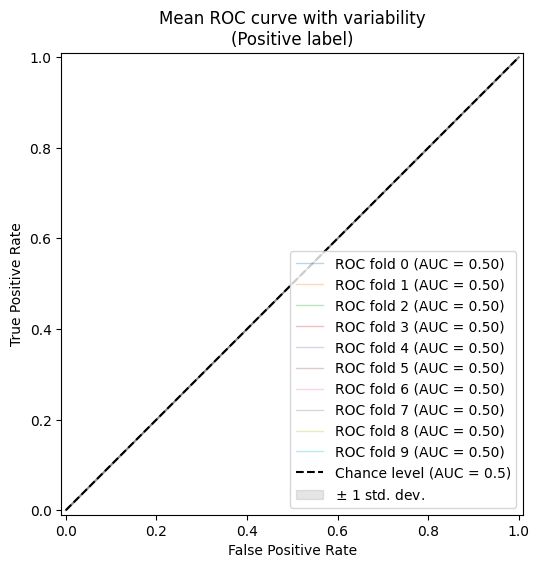

In [68]:
number_of_columns = 11
n_splits = 10

X, y = getData(number_of_columns)
plot3(n_splits, X, y)


In [28]:
#@title Plot4 for Lab
def plot4(n,X,y):
  print("add code here")

In [29]:
# normalize(X, norm='l2')
number_of_columns = 11
n_splits = 10
X,y = getData(number_of_columns)
plot4(n_splits,X,y)

[[3.70594257e-01 4.24389446e-01 4.05749772e-01 6.01457213e-01
  6.01457213e-01 9.98969203e-01 7.96887146e-01 8.08809361e-01
  3.02646434e-01 7.80984850e-01 1.25696869e-04]
 [4.64290937e-01 5.38214130e-01 5.16730018e-01 6.10235086e-01
  6.10235086e-01 9.98945978e-01 7.97380191e-01 8.09300726e-01
  3.03556430e-01 7.81505974e-01 2.89785054e-04]
 [4.26071272e-01 4.99018753e-01 4.72295091e-01 6.01450006e-01
  6.01363525e-01 9.98857353e-01 7.96403369e-01 8.08387521e-01
  3.02035177e-01 7.80283936e-01 2.36129721e-04]
 [3.99844001e-01 4.51264719e-01 4.57733283e-01 5.83541129e-01
  5.83541129e-01 9.98699747e-01 7.96966968e-01 8.08965598e-01
  3.03349536e-01 7.81240991e-01 1.07888849e-04]
 [4.65022181e-01 5.38432185e-01 5.22297768e-01 5.98783494e-01
  5.98783494e-01 9.98973132e-01 7.97366081e-01 8.09303720e-01
  3.03474978e-01 7.81550045e-01 7.89000000e+09]]
add code here


In [30]:
##############################################################################################################################

In [31]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import normalize, StandardScaler

#@title Plot4 for Lab (L2)
def plot4(n, X, y):
  cv = StratifiedKFold(n_splits=n)
  classifier = svm.SVC(kernel="linear", probability=True, random_state=10, max_iter=500)
  tprs = []
  aucs = []
  mean_fpr = np.linspace(0, 1, 100)

  fig, ax = plt.subplots(figsize=(6, 6))
  for fold, (train, test) in enumerate(cv.split(X, y)):

      # Train and test split
      X_train = X[train]
      X_test  = X[test]
      y_train = y[train]
      y_test  = y[test]

      # Normalize L2
      X_train = normalize(X_train, norm='l2')
      X_test  = normalize(X_test,  norm='l2')

      # Standardize
      scaler = StandardScaler()
      X_train = scaler.fit_transform(X_train)   # fit on train
      X_test  = scaler.transform(X_test)        # transform test

      # Train model
      classifier.fit(X_train, y_train)

      viz = RocCurveDisplay.from_estimator(
          classifier,
          X_test,
          y_test,
          name=f"ROC fold {fold}",
          alpha=0.3,
          lw=1,
          ax=ax,
          plot_chance_level=(fold == n - 1),
      )

      interp_tpr = np.interp(mean_fpr, viz.fpr, viz.tpr)
      interp_tpr[0] = 0.0
      tprs.append(interp_tpr)
      aucs.append(viz.roc_auc)

  mean_tpr = np.mean(tprs, axis=0)
  mean_tpr[-1] = 1.0
  mean_auc = auc(mean_fpr, mean_tpr)
  std_auc = np.std(aucs)

  std_tpr = np.std(tprs, axis=0)
  tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
  tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
  ax.fill_between(
      mean_fpr,
      tprs_lower,
      tprs_upper,
      color="grey",
      alpha=0.2,
      label=r"$\pm$ 1 std. dev.",
  )

  ax.set(
      xlabel="False Positive Rate",
      ylabel="True Positive Rate",
      title="Mean ROC curve with variability\n(L2 normalization)",
  )
  ax.legend(loc="lower right")
  plt.show()


[[3.70594257e-01 4.24389446e-01 4.05749772e-01 6.01457213e-01
  6.01457213e-01 9.98969203e-01 7.96887146e-01 8.08809361e-01
  3.02646434e-01 7.80984850e-01 1.25696869e-04]
 [4.64290937e-01 5.38214130e-01 5.16730018e-01 6.10235086e-01
  6.10235086e-01 9.98945978e-01 7.97380191e-01 8.09300726e-01
  3.03556430e-01 7.81505974e-01 2.89785054e-04]
 [4.26071272e-01 4.99018753e-01 4.72295091e-01 6.01450006e-01
  6.01363525e-01 9.98857353e-01 7.96403369e-01 8.08387521e-01
  3.02035177e-01 7.80283936e-01 2.36129721e-04]
 [3.99844001e-01 4.51264719e-01 4.57733283e-01 5.83541129e-01
  5.83541129e-01 9.98699747e-01 7.96966968e-01 8.08965598e-01
  3.03349536e-01 7.81240991e-01 1.07888849e-04]
 [4.65022181e-01 5.38432185e-01 5.22297768e-01 5.98783494e-01
  5.98783494e-01 9.98973132e-01 7.97366081e-01 8.09303720e-01
  3.03474978e-01 7.81550045e-01 7.89000000e+09]]


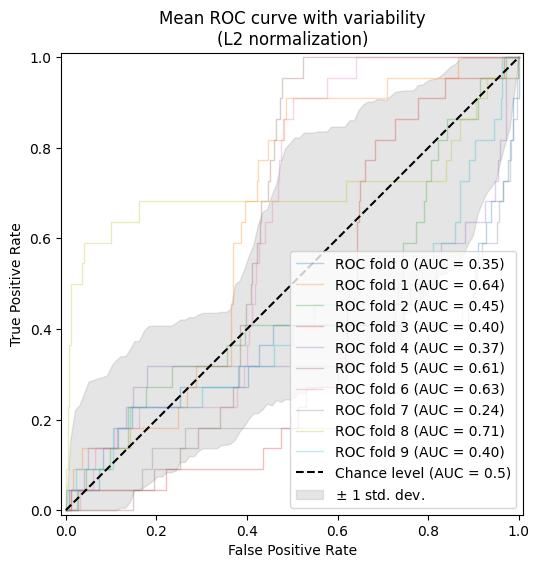

In [32]:
number_of_columns = 11
n_splits = 10
X, y = getData(number_of_columns)
plot4(n_splits, X, y)


In [35]:
#################################################################################################################################

In [56]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import normalize, StandardScaler

#@title Plot5 for Lab (L2 axis=0)
def plot5(n, X, y):
  cv = StratifiedKFold(n_splits=n)
  classifier = svm.SVC(kernel="linear", probability=True, random_state=10, max_iter=500)
  tprs = []
  aucs = []
  mean_fpr = np.linspace(0, 1, 100)

  fig, ax = plt.subplots(figsize=(6, 6))
  for fold, (train, test) in enumerate(cv.split(X, y)):

      #  Train and test split
      X_train = X[train]
      X_test  = X[test]
      y_train = y[train]
      y_test  = y[test]

      #  Normalize L2, axis=0
      X_train = normalize(X_train, norm='l2', axis=0)
      X_test  = normalize(X_test,  norm='l2', axis=0)

      #  Standardize
      scaler = StandardScaler()
      X_train = scaler.fit_transform(X_train)   # fit on train
      X_test  = scaler.transform(X_test)        # transform test

      #  Train model
      classifier.fit(X_train, y_train)

      viz = RocCurveDisplay.from_estimator(
          classifier,
          X_test,
          y_test,
          name=f"ROC fold {fold}",
          alpha=0.3,
          lw=1,
          ax=ax,
          plot_chance_level=(fold == n - 1),
      )

      interp_tpr = np.interp(mean_fpr, viz.fpr, viz.tpr)
      interp_tpr[0] = 0.0
      tprs.append(interp_tpr)
      aucs.append(viz.roc_auc)

  mean_tpr = np.mean(tprs, axis=0)
  mean_tpr[-1] = 1.0
  mean_auc = auc(mean_fpr, mean_tpr)
  std_auc = np.std(aucs)

  std_tpr = np.std(tprs, axis=0)
  tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
  tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
  ax.fill_between(
      mean_fpr,
      tprs_lower,
      tprs_upper,
      color="grey",
      alpha=0.2,
      label=r"$\pm$ 1 std. dev.",
  )

  ax.set(
      xlabel="False Positive Rate",
      ylabel="True Positive Rate",
      title="Mean ROC curve with variability\n(L2 normalization, axis=0)",
  )
  ax.legend(loc="lower right")
  plt.show()


[[3.70594257e-01 4.24389446e-01 4.05749772e-01 6.01457213e-01
  6.01457213e-01 9.98969203e-01 7.96887146e-01 8.08809361e-01
  3.02646434e-01 7.80984850e-01 1.25696869e-04]
 [4.64290937e-01 5.38214130e-01 5.16730018e-01 6.10235086e-01
  6.10235086e-01 9.98945978e-01 7.97380191e-01 8.09300726e-01
  3.03556430e-01 7.81505974e-01 2.89785054e-04]
 [4.26071272e-01 4.99018753e-01 4.72295091e-01 6.01450006e-01
  6.01363525e-01 9.98857353e-01 7.96403369e-01 8.08387521e-01
  3.02035177e-01 7.80283936e-01 2.36129721e-04]
 [3.99844001e-01 4.51264719e-01 4.57733283e-01 5.83541129e-01
  5.83541129e-01 9.98699747e-01 7.96966968e-01 8.08965598e-01
  3.03349536e-01 7.81240991e-01 1.07888849e-04]
 [4.65022181e-01 5.38432185e-01 5.22297768e-01 5.98783494e-01
  5.98783494e-01 9.98973132e-01 7.97366081e-01 8.09303720e-01
  3.03474978e-01 7.81550045e-01 7.89000000e+09]]


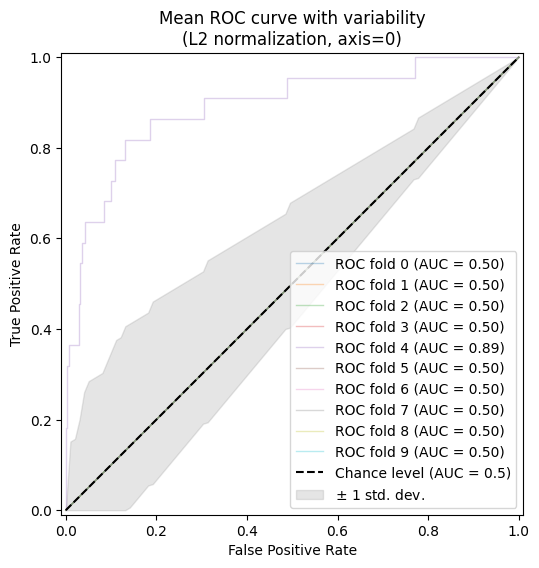

In [57]:
number_of_columns = 11
n_splits = 10
X, y = getData(number_of_columns)
plot5(n_splits, X, y)


##TO-DO

Compare these outputs.
Which normalization practice worked best?
normalize(X, norm='l2') in plot 4 worked best since it normalizes each sample's magnitude but still keeps the relationships between features.